# Tutorial 9: Compare Datasets

## Objective

Quantitatively compare chromatin organization between two experimental conditions.
In this tutorial we compare traces from **Pdx1-positive** cells (inside the Pdx1 mask)
versus **Pdx1-negative** cells (outside the mask), using the split files from Tutorial 6
and the PWD matrices computed in Tutorial 7.

Two complementary scripts are covered:

1. **`plot_matrix_comparison`** — Pearson correlation scatter plot + violin distribution
   comparison (with Wilcoxon rank-sum p-value).
2. **`plot_compare2matrices`** — Side-by-side matrix visualizations: difference matrix,
   mixed matrix (upper/lower triangle), and Wilcoxon statistical-test matrix.

## Scientific context

- **Pearson scatter**: quantifies overall similarity between two distance/proximity matrices.
  r ≈ 1 means highly similar; r ≈ 0 means largely uncorrelated.
- **Violin plot**: compares the full distribution of pairwise values between the two conditions
  (Wilcoxon rank-sum test for significance).
- **Difference matrix**: highlights which barcode pairs change the most between conditions.
- **Mixed matrix**: upper triangle = condition 1, lower triangle = condition 2 — visual
  comparison on a single heatmap.
- **Wilcoxon matrix**: per-barcode-pair statistical significance across single-cell measurements.

## Input

We use the single-cell PWD matrices produced by `trace_to_matrix` (Tutorial 7) for each condition:

| File | Description |
|------|-------------|
| `..._Pdx1_Pdx1_Matrix_PWDscMatrix.npy` | 3D single-cell PWD matrix (Pdx1+) |
| `..._not:Pdx1_Matrix_PWDscMatrix.npy` | 3D single-cell PWD matrix (Pdx1−) |
| `..._Pdx1_Pdx1_Matrix_uniqueBarcodes.ecsv` | Barcode list (shared) |

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob
%matplotlib inline

#Set up your folder data and destination paths:
data_path = "/mnt/grey/DATA/users/zidoum/traceraptops/data/Assign_mask"
dest_path = f"{data_path}/output"

# Single-cell PWD matrices (3D: n_barcodes x n_barcodes x n_traces)
matrix_pdx1_pos = f"{data_path}/Trace_3D_barcode_mask-mask0_ROI-16_Pdx1_Matrix_PWDscMatrix.npy"
matrix_pdx1_neg = f"{data_path}/Trace_3D_barcode_mask-mask0_ROI-16_Pdx1_not:Pdx1_Matrix_PWDscMatrix.npy"

# Unique barcodes (same for both — they come from the same ROI)
barcodes = f"{data_path}/Trace_3D_barcode_mask-mask0_ROI-16_Pdx1_Matrix_uniqueBarcodes.ecsv"

print(f"Pdx1+ matrix: {matrix_pdx1_pos}")
print(f"Pdx1- matrix: {matrix_pdx1_neg}")
print(f"Barcodes:     {barcodes}")

Pdx1+ matrix: /mnt/grey/DATA/users/zidoum/traceraptops/data/Assign_mask/Trace_3D_barcode_mask-mask0_ROI-16_Pdx1_Matrix_PWDscMatrix.npy
Pdx1- matrix: /mnt/grey/DATA/users/zidoum/traceraptops/data/Assign_mask/Trace_3D_barcode_mask-mask0_ROI-16_Pdx1_not:Pdx1_Matrix_PWDscMatrix.npy
Barcodes:     /mnt/grey/DATA/users/zidoum/traceraptops/data/Assign_mask/Trace_3D_barcode_mask-mask0_ROI-16_Pdx1_Matrix_uniqueBarcodes.ecsv


## Step 1: Pearson correlation with `plot_matrix_comparison`

`plot_matrix_comparison` takes two single-cell PWD matrices, computes ensemble averages
(median, KDE, or proximity), flattens the upper triangle into vectors, and:

1. Computes the **Pearson correlation** between the two vectors.
2. Produces a **scatter plot** (dataset 1 vs dataset 2) with the identity line.
3. Produces a **violin plot** comparing the distributions (with Wilcoxon p-value).

### Parameters

| Option | Default | Description |
|--------|---------|-------------|
| `--input1` | — | First single-cell PWD matrix (`.npy`) |
| `--input2` | — | Second single-cell PWD matrix (`.npy`) |
| `--output` | `output.png` | Base name for output plots |
| `--mode` | `median` | Averaging method: `median`, `KDE`, or `proximity` |
| `--scale` | `linear` | Axis scale: `linear` or `log` |
| `--max_distance` | `inf` | Upper distance threshold (µm) |

In [2]:
# Pearson correlation using median distances
!plot_matrix_comparison --input1 {matrix_pdx1_pos} --input2 {matrix_pdx1_neg} --mode median --output {data_path}/comparison_median.png

------- Running plot_matrix_comparison.py --------
Compare PWD matrices from two experiments.

Input parameters
input1-->/mnt/grey/DATA/users/zidoum/traceraptops/data/Assign_mask/Trace_3D_barcode_mask-mask0_ROI-16_Pdx1_Matrix_PWDscMatrix.npy
input2-->/mnt/grey/DATA/users/zidoum/traceraptops/data/Assign_mask/Trace_3D_barcode_mask-mask0_ROI-16_Pdx1_not:Pdx1_Matrix_PWDscMatrix.npy
output-->/mnt/grey/DATA/users/zidoum/traceraptops/data/Assign_mask/comparison_median.png
mode-->median
x_min-->None
x_max-->None
max_distance-->inf
scale-->linear
input_files-->['/mnt/grey/DATA/users/zidoum/traceraptops/data/Assign_mask/Trace_3D_barcode_mask-mask0_ROI-16_Pdx1_Matrix_PWDscMatrix.npy', '/mnt/grey/DATA/users/zidoum/traceraptops/data/Assign_mask/Trace_3D_barcode_mask-mask0_ROI-16_Pdx1_not:Pdx1_Matrix_PWDscMatrix.npy']
> Number of input files: 2
Input files: 
/mnt/grey/DATA/users/zidoum/traceraptops/data/Assign_mask/Trace_3D_barcode_mask-mask0_ROI-16_Pdx1_Matrix_PWDscMatrix.npy
/mnt/grey/DATA/users/z

This produces two plots:

| Output | Description |
|--------|-------------|
| `comparison_median_scatter_plot.png` | Scatter plot with Pearson r |
| `comparison_median_violin_plot.png` | Violin distributions with Wilcoxon p-value |

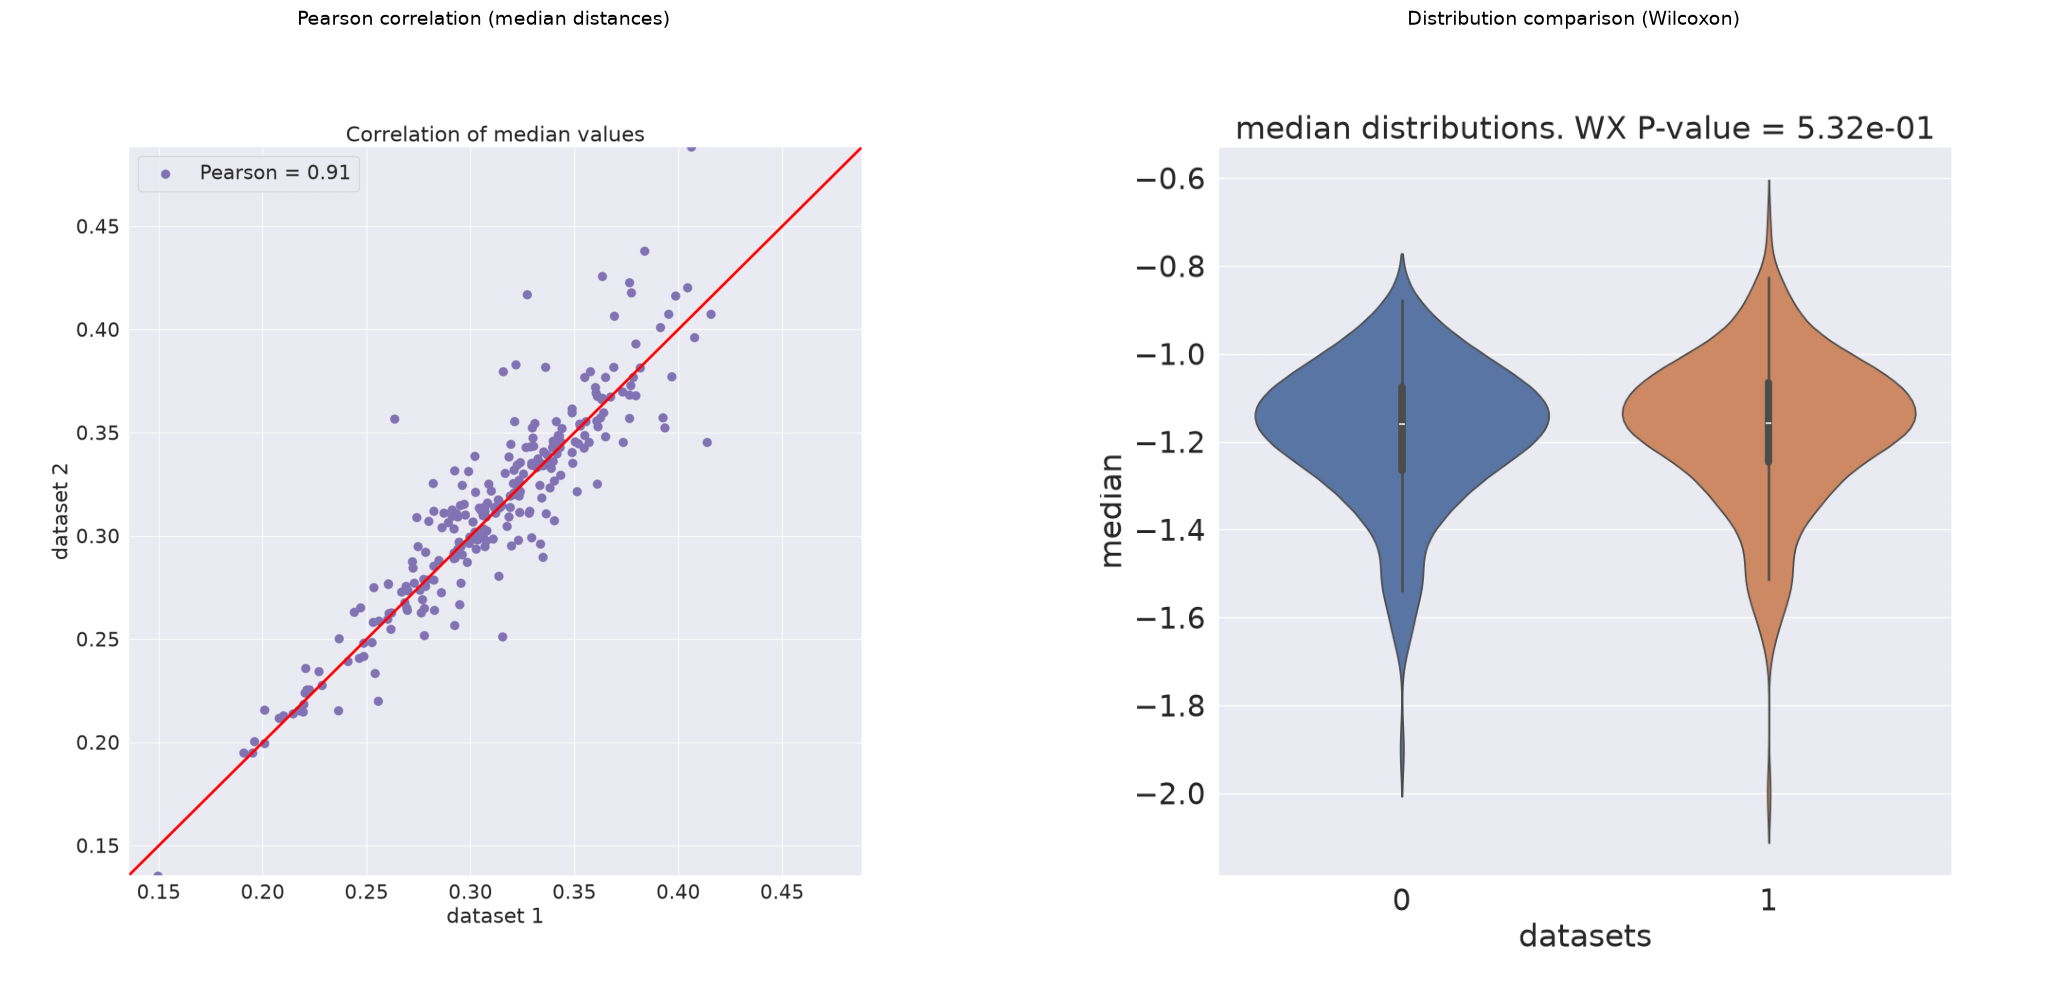

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(22, 10))

scatter_file = f"{data_path}/comparison_median_scatter_plot.png"
violin_file = f"{data_path}/comparison_median_violin_plot.png"

img_scatter = mpimg.imread(scatter_file)
axes[0].imshow(img_scatter)
axes[0].axis('off')
axes[0].set_title("Pearson correlation (median distances)", fontsize=14)

img_violin = mpimg.imread(violin_file)
axes[1].imshow(img_violin)
axes[1].axis('off')
axes[1].set_title("Distribution comparison (Wilcoxon)", fontsize=14)

plt.tight_layout()
plt.show()

**How to read these plots:**

- **Scatter plot**: each point is one barcode pair. Points on the identity line (red)
  mean identical values in both conditions. The Pearson r is shown in the legend.
- **Violin plot**: log-transformed distributions of pairwise values for each dataset.
  The Wilcoxon rank-sum p-value tests whether the two distributions differ significantly.

A high Pearson r (> 0.9) with a non-significant Wilcoxon test suggests the overall
chromatin architecture is conserved between conditions.

### Proximity mode

You can also compare **contact probability** matrices instead of distances.
In proximity mode, the matrix values are the fraction of traces where each barcode pair
is within the contact threshold.

In [4]:
# Pearson correlation using contact proximity
!plot_matrix_comparison --input1 {matrix_pdx1_pos} --input2 {matrix_pdx1_neg} --mode proximity --output {data_path}/comparison_proximity.png

------- Running plot_matrix_comparison.py --------
Compare PWD matrices from two experiments.

Input parameters
input1-->/mnt/grey/DATA/users/zidoum/traceraptops/data/Assign_mask/Trace_3D_barcode_mask-mask0_ROI-16_Pdx1_Matrix_PWDscMatrix.npy
input2-->/mnt/grey/DATA/users/zidoum/traceraptops/data/Assign_mask/Trace_3D_barcode_mask-mask0_ROI-16_Pdx1_not:Pdx1_Matrix_PWDscMatrix.npy
output-->/mnt/grey/DATA/users/zidoum/traceraptops/data/Assign_mask/comparison_proximity.png
mode-->proximity
x_min-->None
x_max-->None
max_distance-->inf
scale-->linear
input_files-->['/mnt/grey/DATA/users/zidoum/traceraptops/data/Assign_mask/Trace_3D_barcode_mask-mask0_ROI-16_Pdx1_Matrix_PWDscMatrix.npy', '/mnt/grey/DATA/users/zidoum/traceraptops/data/Assign_mask/Trace_3D_barcode_mask-mask0_ROI-16_Pdx1_not:Pdx1_Matrix_PWDscMatrix.npy']
> Number of input files: 2
Input files: 
/mnt/grey/DATA/users/zidoum/traceraptops/data/Assign_mask/Trace_3D_barcode_mask-mask0_ROI-16_Pdx1_Matrix_PWDscMatrix.npy
/mnt/grey/DATA/u

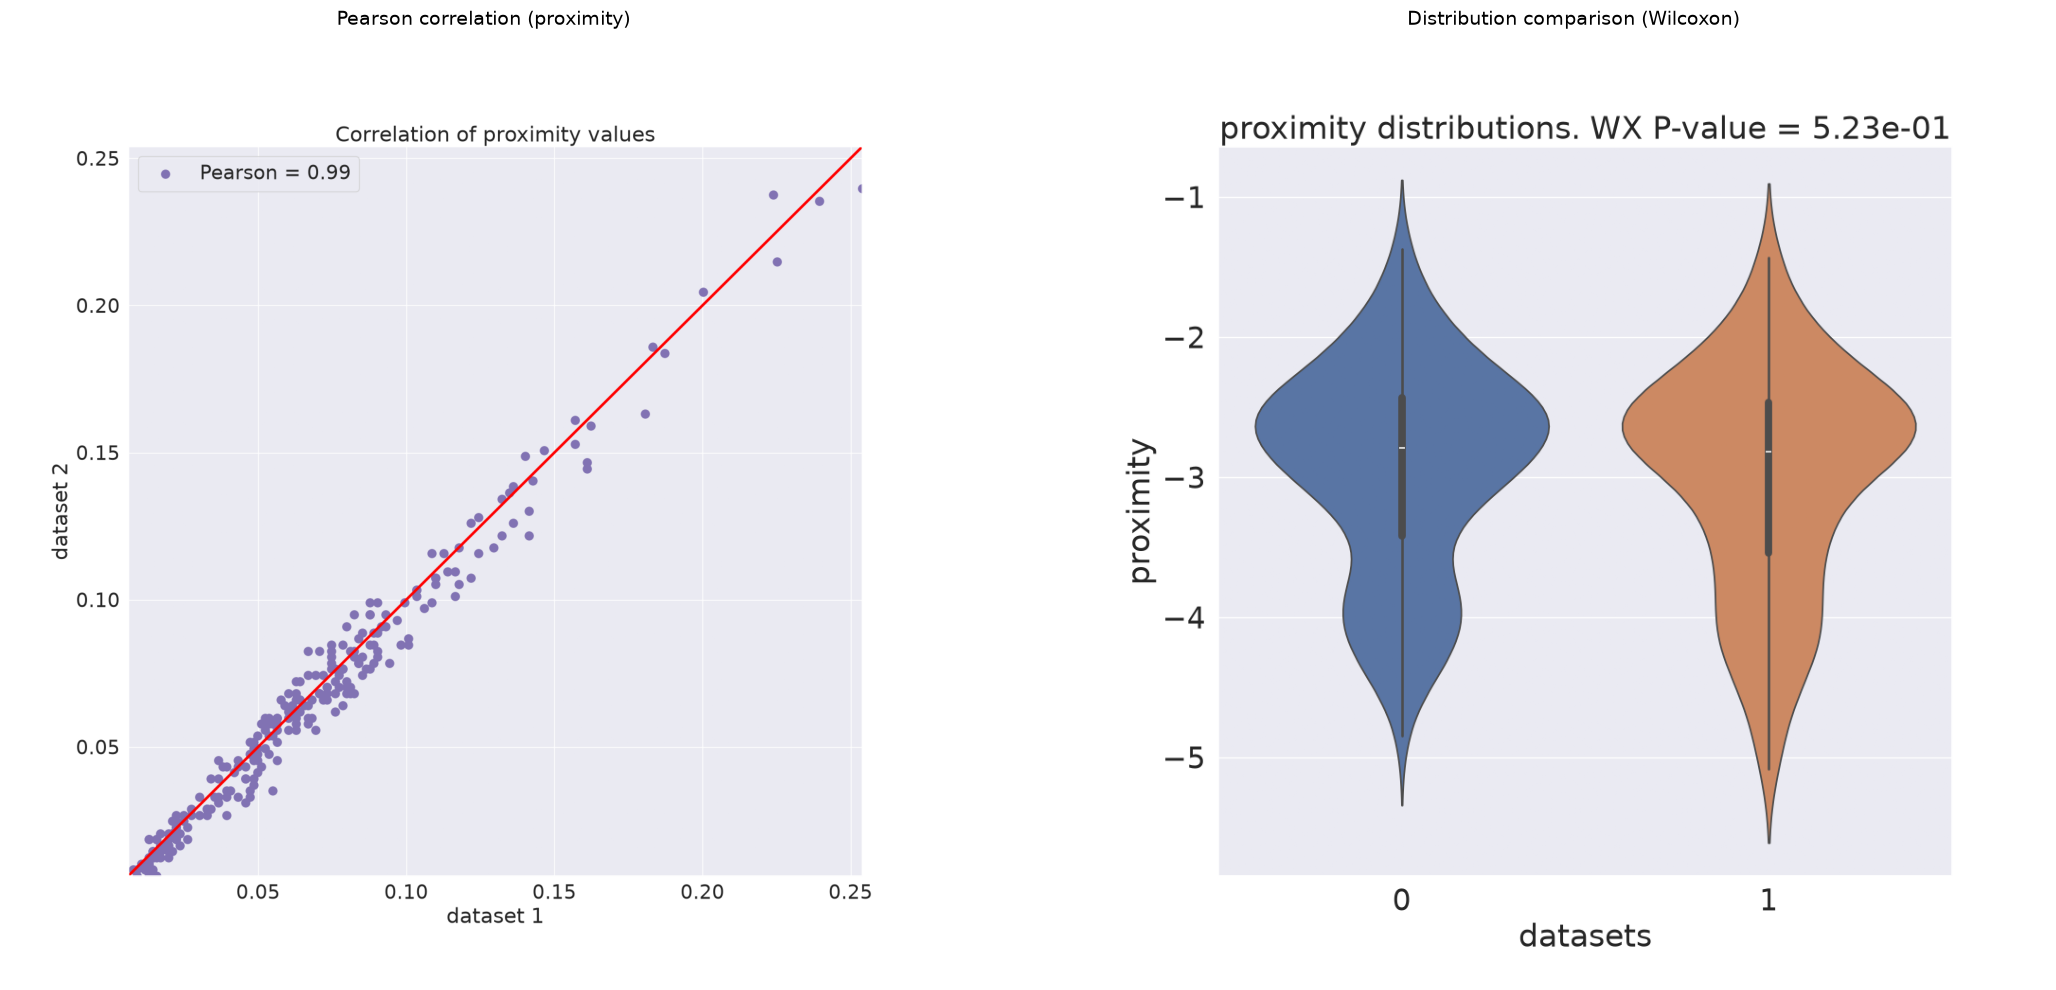

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(22, 10))

scatter_file = f"{data_path}/comparison_proximity_scatter_plot.png"
violin_file = f"{data_path}/comparison_proximity_violin_plot.png"

img_scatter = mpimg.imread(scatter_file)
axes[0].imshow(img_scatter)
axes[0].axis('off')
axes[0].set_title("Pearson correlation (proximity)", fontsize=14)

img_violin = mpimg.imread(violin_file)
axes[1].imshow(img_violin)
axes[1].axis('off')
axes[1].set_title("Distribution comparison (Wilcoxon)", fontsize=14)

plt.tight_layout()
plt.show()

## Step 2: Matrix-level comparison with `plot_compare2matrices`

`plot_compare2matrices` produces three publication-quality visualizations that compare
two Hi-M matrices element by element:

1. **Difference matrix** — subtracts matrix 2 from matrix 1 (or computes the ratio).
   Highlights which barcode pairs change the most.
2. **Mixed matrix** — upper triangle from matrix 1, lower triangle from matrix 2.
   Allows direct visual comparison on a single heatmap.
3. **Wilcoxon matrix** — per-barcode-pair Wilcoxon test across single-cell measurements.
   Shows which pairs have statistically significant differences. *(Only for median/KDE mode.)*

### Parameters

| Option | Default | Description |
|--------|---------|-------------|
| `-T1` / `--input1` | — | First single-cell PWD matrix (`.npy`) |
| `-T2` / `--input2` | — | Second single-cell PWD matrix (`.npy`) |
| `-U` / `--uniqueBarcodes` | — | Unique barcodes file (`.ecsv`) |
| `-O` / `--outputFolder` | `plots` | Output folder |
| `--dist_calc_mode` | `median` | Averaging: `median`, `KDE`, or `proximity` |
| `--ratio` | off | Compute ratio instead of difference |
| `--normalize` | `none` | Normalization: `maximum`, `none`, or a numeric value |
| `--proximity_threshold` | `0.25` | Contact threshold in µm (for proximity mode) |
| `--cmap` | `coolwarm` | Colormap |
| `--plottingFileExtension` | `svg` | Output format: `svg`, `pdf`, or `png` |

In [20]:
# Compare matrices using median distances (produces difference, mixed, and Wilcoxon plots)
!plot_compare2matrices -T1 {matrix_pdx1_pos} -T2 {matrix_pdx1_neg} -U {barcodes} --dist_calc_mode median -O {data_path}/comparison_plots

------- Running plot_compare2matrices.py --------
Compare two proximity matrices.

Input parameters:{'input1': '/mnt/grey/DATA/users/zidoum/traceraptops/data/Assign_mask/Trace_3D_barcode_mask-mask0_ROI-16_Pdx1_Matrix_PWDscMatrix.npy', 'input2': '/mnt/grey/DATA/users/zidoum/traceraptops/data/Assign_mask/Trace_3D_barcode_mask-mask0_ROI-16_Pdx1_not:Pdx1_Matrix_PWDscMatrix.npy', 'uniqueBarcodes': '/mnt/grey/DATA/users/zidoum/traceraptops/data/Assign_mask/Trace_3D_barcode_mask-mask0_ROI-16_Pdx1_Matrix_uniqueBarcodes.ecsv', 'outputFolder': '/mnt/grey/DATA/users/zidoum/traceraptops/data/Assign_mask/comparison_plots', 'proximity_threshold': 0.25, 'cmap': 'coolwarm', 'fontsize': 12, 'pixelSize': 1, 'axisLabel': True, 'axisTicks': True, 'ratio': False, 'plottingFileExtension': '.png', 'normalize': 'none', 'dist_calc_mode': 'median', 'cmtitle': 'distance, um', 'matrix_norm_mode': 'n_cells', 'cMax': 0.0, 'scalingParameter': 1, 'shuffle': 0, 'cMin': 0.0}
********************************************

This produces three plots in the output folder:

| Output | Description |
|--------|-------------|
| `*_difference.png` | Difference heatmap (matrix 1 − matrix 2) |
| `*_mixed_matrix.png` | Upper triangle = Pdx1+, lower = Pdx1− |
| `*_Wilcoxon.png` | Per-pair Wilcoxon p-value heatmap |

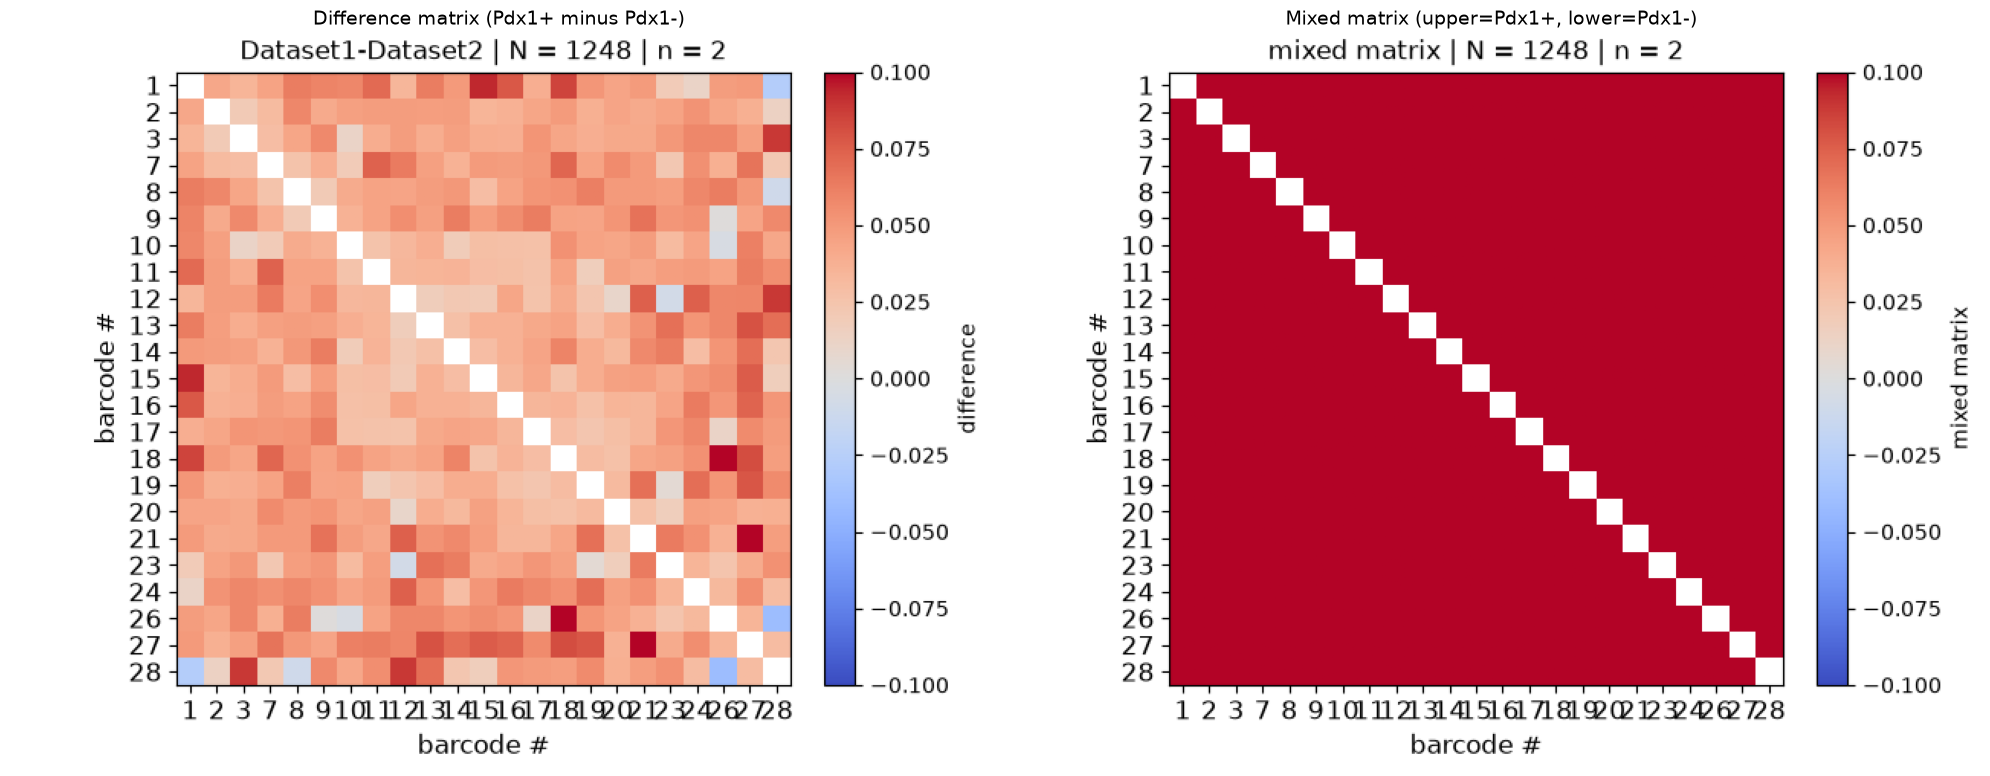

In [6]:
plots_dir = f"{data_path}/comparison_plots"

# Find the generated plots
diff_matches = sorted(glob.glob(f"{plots_dir}/*_difference.png"))
mixed_matches = sorted(glob.glob(f"{plots_dir}/*_mixed_matrix.png"))
wilcoxon_matches = sorted(glob.glob(f"{plots_dir}/*_Wilcoxon.png"))

if diff_matches and mixed_matches:
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    img = mpimg.imread(diff_matches[0])
    axes[0].imshow(img)
    axes[0].axis('off')
    axes[0].set_title("Difference matrix (Pdx1+ minus Pdx1-)", fontsize=14)

    img = mpimg.imread(mixed_matches[0])
    axes[1].imshow(img)
    axes[1].axis('off')
    axes[1].set_title("Mixed matrix (upper=Pdx1+, lower=Pdx1-)", fontsize=14)

    plt.tight_layout()
    plt.show()

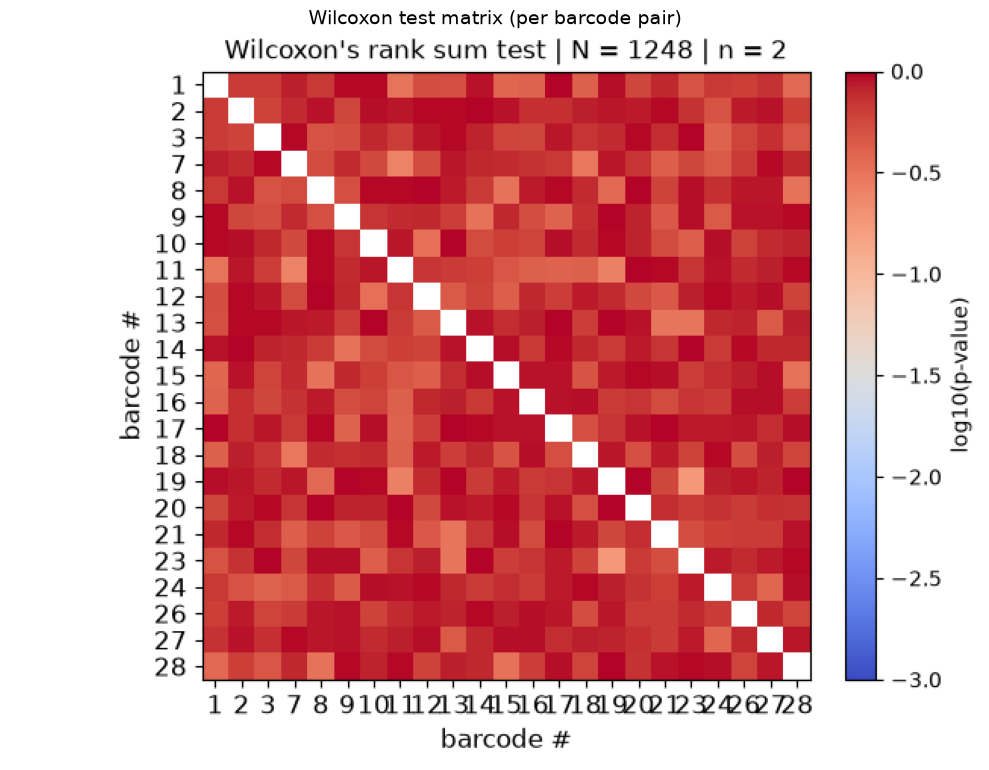

In [7]:
if wilcoxon_matches:
    img = mpimg.imread(wilcoxon_matches[0])
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title("Wilcoxon test matrix (per barcode pair)", fontsize=14)
    plt.tight_layout()
    plt.show()

**How to read these plots:**

- **Difference matrix**: warm colors indicate barcode pairs that are closer (or more frequent)
  in Pdx1+ than Pdx1−, and vice versa for cool colors. Values near zero (white) mean no
  difference.
- **Mixed matrix**: the upper triangle shows Pdx1+ and the lower triangle shows Pdx1−
  on the same color scale. Asymmetries across the diagonal reveal condition-specific contacts.
- **Wilcoxon matrix**: each cell shows the p-value from a per-barcode-pair Wilcoxon rank-sum
  test on single-cell distance measurements. Low p-values (dark) indicate pairs where the
  distance distributions differ significantly between conditions.

### Proximity mode comparison

You can also compare **contact probability** matrices. Note that in proximity mode,
the Wilcoxon per-pair matrix is not computed (it requires single-cell distance distributions).

In [8]:
# Compare matrices using contact proximity
!plot_compare2matrices -T1 {matrix_pdx1_pos} -T2 {matrix_pdx1_neg} -U {barcodes} --dist_calc_mode proximity -O {data_path}/comparison_plots_proximity

------- Running plot_compare2matrices.py --------
Compare two proximity matrices.

Input parameters:{'input1': '/mnt/grey/DATA/users/zidoum/traceraptops/data/Assign_mask/Trace_3D_barcode_mask-mask0_ROI-16_Pdx1_Matrix_PWDscMatrix.npy', 'input2': '/mnt/grey/DATA/users/zidoum/traceraptops/data/Assign_mask/Trace_3D_barcode_mask-mask0_ROI-16_Pdx1_not:Pdx1_Matrix_PWDscMatrix.npy', 'uniqueBarcodes': '/mnt/grey/DATA/users/zidoum/traceraptops/data/Assign_mask/Trace_3D_barcode_mask-mask0_ROI-16_Pdx1_Matrix_uniqueBarcodes.ecsv', 'outputFolder': '/mnt/grey/DATA/users/zidoum/traceraptops/data/Assign_mask/comparison_plots_proximity', 'proximity_threshold': 0.25, 'cmap': 'coolwarm', 'fontsize': 12, 'pixelSize': 1, 'axisLabel': True, 'axisTicks': True, 'ratio': False, 'plottingFileExtension': '.png', 'normalize': 'none', 'dist_calc_mode': 'proximity', 'cmtitle': 'proximity frequency', 'matrix_norm_mode': 'n_cells', 'cMax': 0.0, 'scalingParameter': 1, 'shuffle': 0, 'cMin': 0.0}
************************

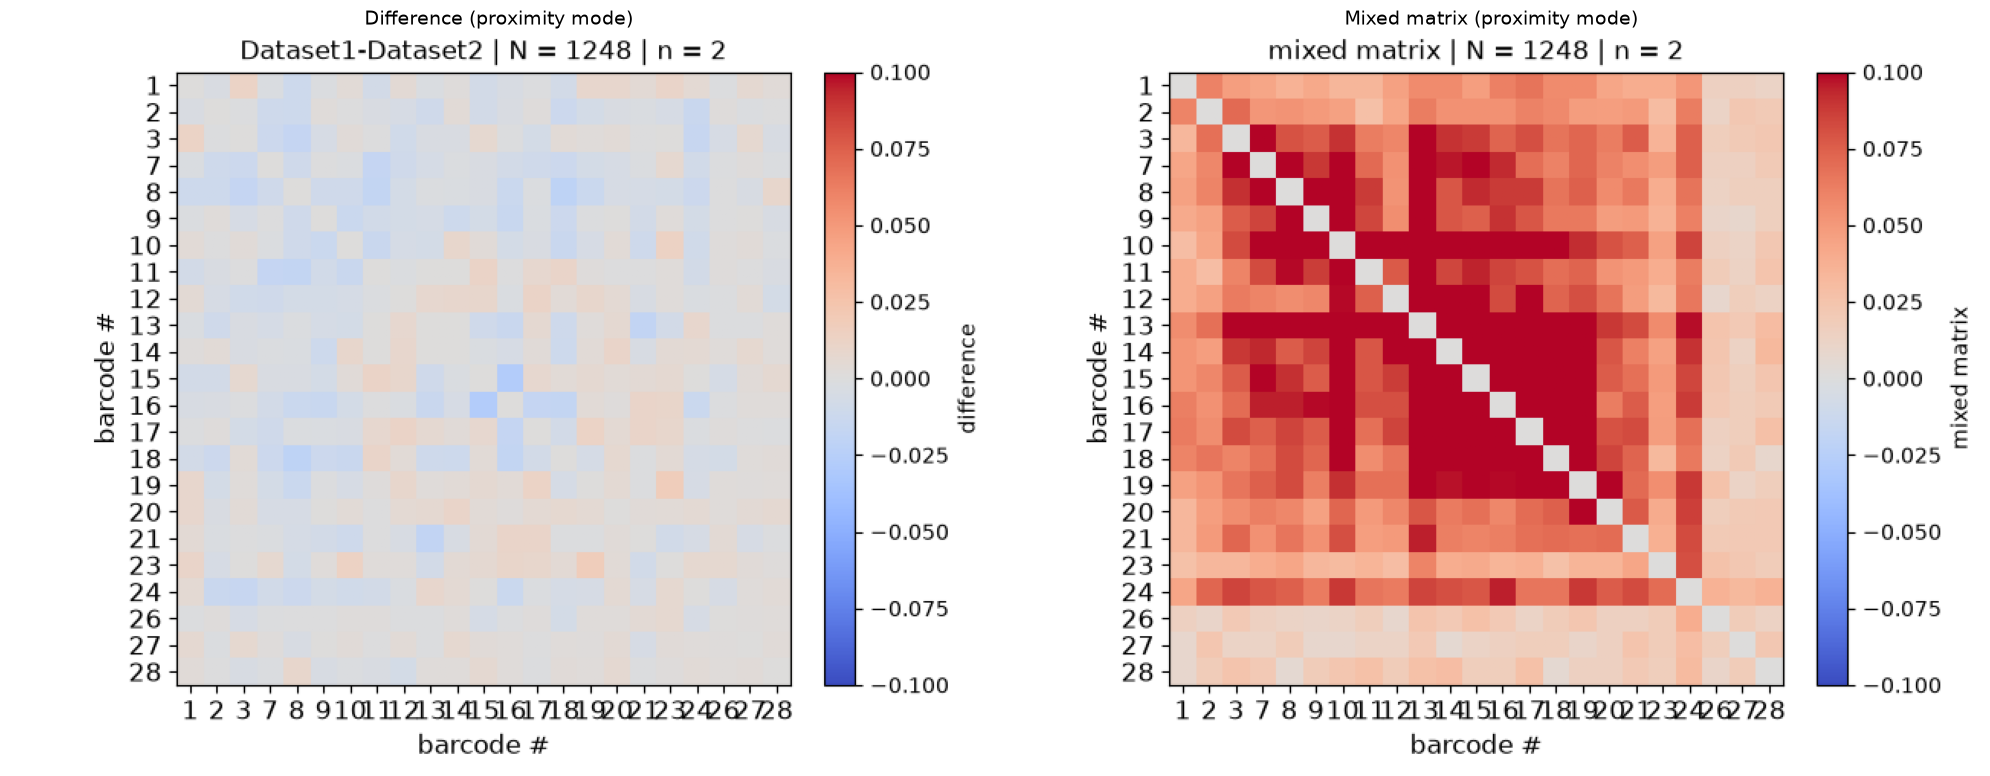

In [9]:
plots_dir_prox = f"{data_path}/comparison_plots_proximity"

diff_matches = sorted(glob.glob(f"{plots_dir_prox}/*_difference.png"))
mixed_matches = sorted(glob.glob(f"{plots_dir_prox}/*_mixed_matrix.png"))

if diff_matches and mixed_matches:
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    img = mpimg.imread(diff_matches[0])
    axes[0].imshow(img)
    axes[0].axis('off')
    axes[0].set_title("Difference (proximity mode)", fontsize=14)

    img = mpimg.imread(mixed_matches[0])
    axes[1].imshow(img)
    axes[1].axis('off')
    axes[1].set_title("Mixed matrix (proximity mode)", fontsize=14)

    plt.tight_layout()
    plt.show()

## Summary

### Workflow

```
condition 1 PWD matrix (.npy)  ──┐
                                  ├─── plot_matrix_comparison    →  scatter + violin
condition 2 PWD matrix (.npy)  ──┤
                                  ├─── plot_compare2matrices     →  difference + mixed + Wilcoxon
unique barcodes (.ecsv)  ────────┘
```

### Commands reference

```bash
# Pearson correlation + violin distributions
plot_matrix_comparison --input1 matrix1.npy --input2 matrix2.npy --mode median --output comparison.png

# Difference, mixed, and Wilcoxon matrices
plot_compare2matrices -T1 matrix1.npy -T2 matrix2.npy -U barcodes.ecsv --dist_calc_mode median -O output_folder
```

### Key differences between the two scripts

| | `plot_matrix_comparison` | `plot_compare2matrices` |
|---|---|---|
| Input | Two `.npy` PWD matrices | Two `.npy` PWD matrices + barcodes file |
| Approach | Global (whole matrix → vector) | Element-wise (per barcode pair) |
| Output | Scatter plot + violin | Difference + mixed + Wilcoxon heatmaps |
| Best for | Overall similarity assessment | Identifying specific pairs that change |

### Modes

| Mode | What it compares |
|------|------------------|
| `median` | Median pairwise 3D distance per barcode pair |
| `KDE` | KDE peak distance per barcode pair |
| `proximity` | Contact probability (fraction of traces below threshold) |

### Notes

- Both matrices must have the **same dimensions** (same barcode ordering).
  This is guaranteed when both come from the same ROI split by label.
- The **Wilcoxon per-pair matrix** is only available in `median` or `KDE` mode
  (not in `proximity` mode, which produces binary counts rather than distances).
- Use `--ratio` with `plot_compare2matrices` to compute the ratio instead of the
  difference between matrices.
- Output format can be changed with `--plottingFileExtension` (`svg`, `pdf`, `png`).
